# Signal→points association across minutes-bands *(population)*

*Read-only informative artifact (EDA). Sits in the **Descriptive** tier: it
**visualises** how each signal's rank-correlation (Spearman rho) with
`total_points` behaves across the minutes bands (`1-29 / 30-59 / 60+`). The
priority is **seeing and understanding** the pattern — no classification, no
gate, no verdict, no causal claim.*

## Questions this notebook answers

- **Where on the minutes axis does each signal actually track points?** Is a
  signal's association with scoring present in cameos, or does it only emerge once
  the player clears 60 minutes?
- **Which signals are minutes-independent** (an event that scores regardless of
  time on the pitch) **versus minutes-dependent** (only relate to points once a
  full match has accumulated)?

This is the closing descriptive view of the `population/` layer: having described
the minutes axis (`minutes_distribution`), Y across bands
(`points_by_minutes_band`) and X across bands (`signals_by_minutes_band`), this
looks at the **X↔Y association** across the same bands. *Explaining* the pattern —
e.g. minutes-adjusted (partial) rho — is the deferred Diagnostic tier.

## Setup

Load the mart, restrict to the whole season (GW 1 .. data_cutoff_gw), the
participation population (`minutes > 0`), DGW excluded; assign each row a minutes
band (`1-29 / 30-59 / 60+`). For every (signal, position, band) we compute the
Spearman rho between the signal and `total_points`.

A cell is **testable** only when the band has enough rows (n ≥ 30) and both the
signal and `total_points` vary within it. In the cameo bands `total_points` has
much less spread (most cameos return the appearance point), so sparse signals are
often untestable there — those cells are left blank, which is itself part of the
story.

Signal universe matches `signals_by_minutes_band` (raw per-GW numerics, excluding
`starts` and the exact composites `ict_index` / `xgi`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from IPython.display import display

from dal.pipeline import load as load_mart, run as run_pipeline
from dal.exceptions import MartNotBuiltError, MartSchemaError

try:
    _result = load_mart()
except (MartNotBuiltError, MartSchemaError) as _e:
    print(f"Rebuilding mart ({type(_e).__name__})...")
    run_pipeline(force=True)
    _result = load_mart()

STUDY_GW_MIN = 1
STUDY_GW_MAX = _result.data_cutoff_gw
TARGET = "total_points"
MIN_N = 30   # min rows in a (signal, position, band) cell to compute rho

mart = _result.mart
df = mart[mart["gw"].between(STUDY_GW_MIN, STUDY_GW_MAX)].copy()
df = df[df["minutes"].notna() & (df["minutes"] > 0)].copy()
df = df[df["is_dgw"] == False].copy()   # single-fixture base population

BAND_ORDER = ["1-29", "30-59", "60+"]

def _band(mn):
    return "1-29" if mn < 30 else "30-59" if mn < 60 else "60+"

df["band"] = df["minutes"].astype(int).map(_band)

POSITIONS = ["GK", "DEF", "MID", "FWD"]

# Signal universe: matches signals_by_minutes_band -- raw per-GW numerics, excluding
# identity/market/structural/context/rolling, `starts` (minutes proxy), and the
# exact composites ict_index (=I+C+T) and xgi (=xg+xa).
_EXCLUDE = {
    "player_id", "gw", "position_code", "team_id",
    "purchase_price", "minutes", "total_points", "starts",
    "ict_index", "xgi",
    "is_bgw", "is_dgw", "is_warmup_gw",
    "fdr_avg", "xgc", "home_count", "away_count", "fixture_count",
    "is_live", "is_next", "is_previous", "finished",
    "transfers_in", "transfers_out", "ownership_count",
}
SIGNALS = sorted(
    c for c in df.select_dtypes(include="number").columns
    if c not in _EXCLUDE and "_roll" not in c and not c.endswith("_trend")
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", "{:.2f}".format)

print(f"Study range: GW {STUDY_GW_MIN} - GW {STUDY_GW_MAX} (whole season, from mart data_cutoff_gw)")
print(f"Population: minutes > 0, DGW excluded, n = {len(df):,} player-gameweeks")
print("Points variance by band (why cameo cells are often untestable):")
for b in BAND_ORDER:
    print(f"  {b}: var(total_points) = {df.loc[df.band == b, TARGET].var():.2f}, n = {int((df.band == b).sum()):,}")
print(f"Signals ({len(SIGNALS)}):", SIGNALS)

Study range: GW 1 - GW 38 (whole season, from mart data_cutoff_gw)
Population: minutes > 0, DGW excluded, n = 11,190 player-gameweeks
Points variance by band (why cameo cells are often untestable):
  1-29: var(total_points) = 1.56, n = 2,553
  30-59: var(total_points) = 2.45, n = 1,030
  60+: var(total_points) = 9.98, n = 7,607
Signals (21): ['assists', 'bonus', 'bps', 'clean_sheets', 'clearances_blocks_interceptions', 'creativity', 'defensive_contribution', 'goals_conceded', 'goals_scored', 'influence', 'own_goals', 'penalties_missed', 'penalties_saved', 'recoveries', 'red_cards', 'saves', 'tackles', 'threat', 'xa', 'xg', 'yellow_cards']


## (a) Spearman rho (signal ↔ total_points) within each minutes band

**What we measure** — for every (signal, position, band), the Spearman
rank-correlation between the signal and `total_points`. Cells with n < 30 or no
variance are left blank (untestable). Shown wide: one row per (signal, position),
one column per band.

**What it means** — read a row left-to-right (`1-29 → 60+`) to see *where* a
signal starts tracking points. A rho near 0 in cameos that rises at `60+` means
the association only appears in genuine outings; a rho already high in cameos
means the signal scores regardless of minutes.

**What it doesn't mean** — a **descriptive**, season-pooled association, not
causal and not minutes-adjusted (that is the deferred Diagnostic tier). Spearman
is rank-based: a near-zero rho means no monotone rank link, not "no relationship
of any shape".

In [2]:
def _rho_cell(frame, signal):
    """Spearman rho(signal, total_points) on one (position, band) cell, or NaN if
    untestable (too few rows, or no variance in signal or target)."""
    x = frame[signal].astype(float)
    y = frame[TARGET].astype(float)
    if len(frame) < MIN_N or x.nunique() < 2 or y.nunique() < 2:
        return np.nan
    return x.corr(y, method="spearman")

rows = []
for s in SIGNALS:
    for p in POSITIONS:
        for b in BAND_ORDER:
            c = df[(df["position"] == p) & (df["band"] == b)]
            rows.append({"signal": s, "position": p, "band": b,
                         "n": len(c), "rho": _rho_cell(c, s)})
rho_long = pd.DataFrame(rows)
rho_wide = (rho_long.pivot_table(index=["signal", "position"], columns="band",
                                 values="rho", observed=True)
            .reindex(columns=BAND_ORDER))

ncells = len(SIGNALS) * len(POSITIONS)
print(f"Testable (signal, position) cells per band, of {ncells}:")
for b in BAND_ORDER:
    print(f"  {b}: {int(rho_long.loc[rho_long.band == b, 'rho'].notna().sum())}")
display(rho_wide.round(2))

Testable (signal, position) cells per band, of 84:
  1-29: 47
  30-59: 48
  60+: 72


band                   1-29  30-59   60+
signal       position                   
assists      DEF       0.44   0.30  0.26
             FWD       0.37   0.40  0.37
             GK         NaN    NaN  0.08
             MID       0.60   0.49  0.49
bonus        DEF       0.12    NaN  0.54
...                     ...    ...   ...
xg           MID       0.19   0.18  0.26
yellow_cards DEF      -0.65  -0.51 -0.23
             FWD      -0.22  -0.30 -0.09
             GK         NaN    NaN -0.14
             MID      -0.61  -0.60 -0.26

[72 rows x 3 columns]

## (b) Heatmap — where each signal's association with points lives

**What we measure** — the same rho as (a), as a heatmap per position: rows =
signals (sorted by their `60+` rho), columns = the three bands, colour = rho on a
diverging scale centred at 0 (red = positive, blue = negative). Untestable cells
are grey.

**What it means** — the eye-level read of (a). A row that is pale in the cameo
columns and bright red at `60+` is a signal whose link to points only emerges in
genuine outings; a row red across all three columns tracks points even in short
appearances; blue marks signals that *cost* points (cards, conceding).

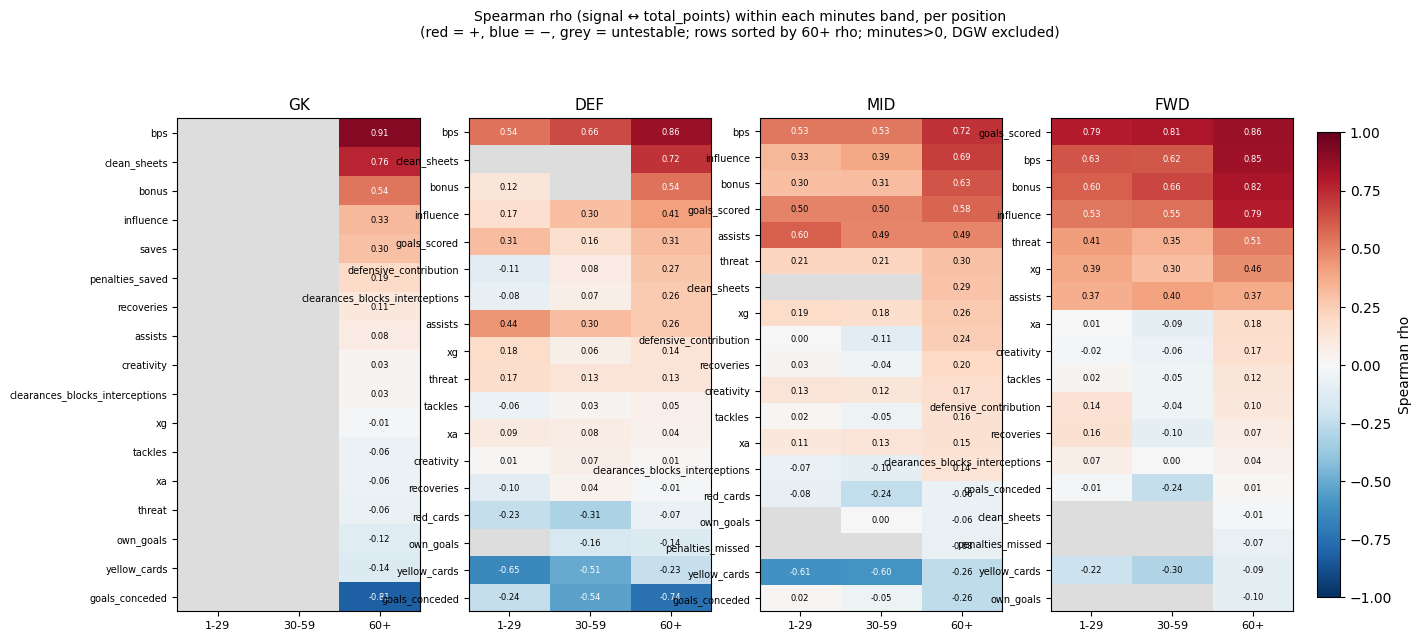

In [3]:
# Heatmap of within-band rho, per position. Diverging colour centred at 0
# (red=+, blue=−); untestable cells grey. Rows sorted by 60+ rho.
cmap = mpl.cm.RdBu_r.copy()
cmap.set_bad("#dddddd")

fig, axes = plt.subplots(1, len(POSITIONS), figsize=(15, 6.4), sharey=False)
for ax, p in zip(axes, POSITIONS):
    mat = rho_wide.xs(p, level="position").reindex(columns=BAND_ORDER)
    mat = mat.loc[mat["60+"].sort_values(ascending=False, na_position="last").index]
    arr = np.ma.masked_invalid(mat.to_numpy(dtype=float))
    im = ax.imshow(arr, aspect="auto", cmap=cmap, vmin=-1, vmax=1)
    ax.set_xticks(range(len(BAND_ORDER)))
    ax.set_xticklabels(BAND_ORDER, fontsize=8)
    ax.set_yticks(range(len(mat)))
    ax.set_yticklabels(mat.index, fontsize=7)
    ax.set_title(p, fontsize=11)
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            v = mat.iloc[i, j]
            if pd.notna(v):
                ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=6,
                        color="white" if abs(v) > 0.5 else "black")
fig.suptitle("Spearman rho (signal ↔ total_points) within each minutes band, per position\n"
             "(red = +, blue = −, grey = untestable; rows sorted by 60+ rho; minutes>0, DGW excluded)",
             y=1.05, fontsize=10)
fig.colorbar(im, ax=axes, fraction=0.02, pad=0.02, label="Spearman rho")
plt.show()

## What the association-by-band picture says

EDA description (no verdict, no classification, no causal claim). Figures below
are **pooled across positions** for the narrative; the per-position split is in
the (a) table and (b) heatmap.

- **Event signals track points in *every* band — even cameos.** A goal or assist
  returns points regardless of how long the player was on, so `goals_scored`
  (pooled rho **0.55 / 0.46 / 0.48** across 1-29 / 30-59 / 60+), `assists`
  (0.51 / 0.41 / 0.36), `bps` (0.55 / 0.59 / **0.82**) and `bonus`
  (0.37 / 0.31 / 0.60) already correlate strongly with points in short
  appearances. `bps` climbs monotonically — the bonus system rewards full-match
  involvement.
- **Accumulating / defensive signals only relate to points at 60+.**
  `defensive_contribution` (0.01 / −0.05 / **0.21**),
  `clearances_blocks_interceptions`, `tackles`, `recoveries` sit at ~0 in cameos
  and only emerge in the 60+ band — they need a full match to accumulate (and DC /
  clean-sheet points live at 60+). `clean_sheets` is **only testable at 60+**
  (rho 0.49) — structural, since a clean sheet requires 60 minutes.
- **The negatives move too, in opposite directions.** `yellow_cards` hurts
  *more* in cameos (−0.53 / −0.54 / −0.21) — a booking dominates a tiny cameo
  return — while `goals_conceded` hurts *more* at 60+ (−0.04 / −0.23 / **−0.49**),
  since conceding only bites players on long enough to lose the clean sheet.
- **Testable cells:** 47 / 48 / 72 of 84 (1-29 / 30-59 / 60+). The blank cameo
  cells are part of the story — sparse signals × low target variance — not an
  error.

So it is **not** simply "associations only appear at 60+": **event-driven signals
are minutes-independent** (a goal is a goal), while **accumulation / defensive
signals are minutes-dependent** (they need the full outing). That split is the EDA
finding.

*Footnote (the old scope contrast).* Comparing the two cumulative populations
directly — `minutes > 0` vs `minutes >= 60` — the rank-correlation shifts for many
signal-position pairs; the per-band view above shows *where* and *why*. Spearman
rho here is a descriptive, season-pooled association — not causal and not
minutes-adjusted (partial rho / per-90 is the deferred Diagnostic tier).